In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(1)


In [3]:
layers = []
for i in range(20):
    layers.append(torch.nn.Linear(50, 50))
    layers.append(torch.nn.ReLU())


In [4]:
model = torch.nn.Sequential(*layers)


In [5]:
for layer in model:
    if isinstance(layer, torch.nn.Linear):
        std = np.sqrt(2 / (layer.in_features + layer.out_features))
        layer.weight.data.normal_(0, std)
        layer.bias.data.zero_()

In [6]:
x = torch.randn(32, 50)

In [7]:
means = []
variances = []

for layer in model:
    x = layer(x)
    if isinstance(layer, torch.nn.ReLU):
        means.append(x.mean().item())
        variances.append(x.var().item())


In [8]:
print("Activation means:")
print(means)

print("Activation variances:")
print(variances)

Activation means:
[0.38779422640800476, 0.2590946853160858, 0.1850016564130783, 0.1330537647008896, 0.08581191301345825, 0.06151478737592697, 0.07686867564916611, 0.0536675825715065, 0.03677470609545708, 0.02382848970592022, 0.013597999699413776, 0.009728362783789635, 0.006766278296709061, 0.00626921933144331, 0.003829550463706255, 0.0030370347667485476, 0.0021180680487304926, 0.0016414865385740995, 0.0010812402470037341, 0.0008656473364681005]
Activation variances:
[0.3440400958061218, 0.15243369340896606, 0.07047590613365173, 0.03921882435679436, 0.01613977551460266, 0.009448324330151081, 0.009515541605651379, 0.006620936561375856, 0.0032871710136532784, 0.0016243642894551158, 0.0004463956574909389, 0.00024292946909554303, 0.0001387956872349605, 8.42498557176441e-05, 5.556419273489155e-05, 2.4856282834662125e-05, 1.2188562322990038e-05, 6.884426056785742e-06, 3.17807143801474e-06, 2.0359345853648847e-06]


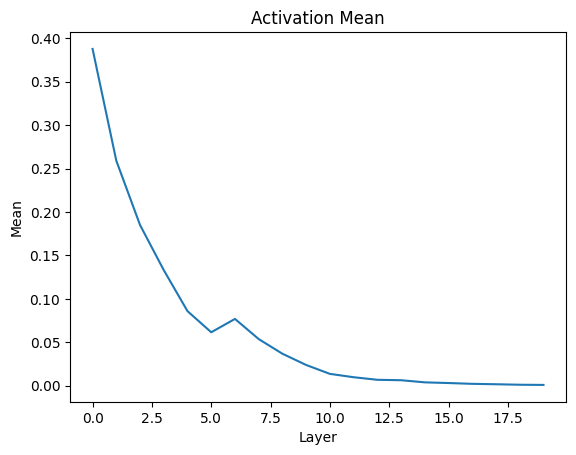

In [9]:
plt.plot(means)
plt.title("Activation Mean")
plt.xlabel("Layer")
plt.ylabel("Mean")
plt.show()


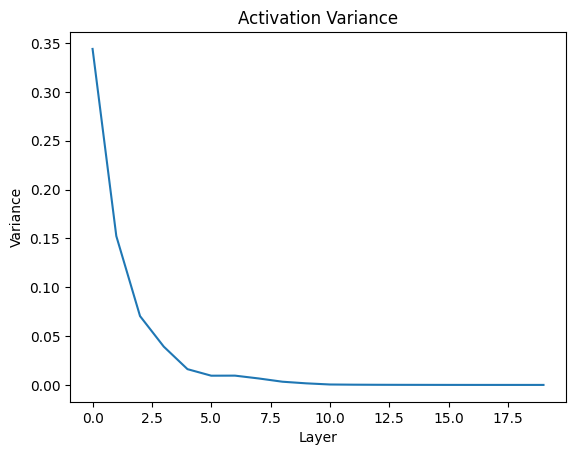

In [10]:
plt.plot(variances)
plt.title("Activation Variance")
plt.xlabel("Layer")
plt.ylabel("Variance")
plt.show()


In [11]:
for layer in model:
    if isinstance(layer, torch.nn.Linear):
        std = np.sqrt(2 / layer.in_features)
        layer.weight.data.normal_(0, std)
        layer.bias.data.zero_()

In [12]:
x = torch.randn(32, 50)
means2 = []
variances2 = []

In [13]:
for layer in model:
    x = layer(x)
    if isinstance(layer, torch.nn.ReLU):
        means2.append(x.mean().item())
        variances2.append(x.var().item())

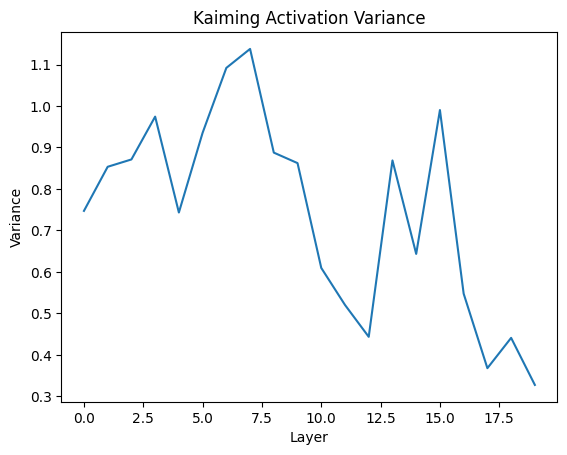

In [14]:
plt.plot(variances2)
plt.title("Kaiming Activation Variance")
plt.xlabel("Layer")
plt.ylabel("Variance")
plt.show()
